# Ecommerce Analytics — Data Cleaning & Exploratory Analysis

**Source files:** `ECA_Orders.xlsx`, `ECA_Payments.xlsx`, `ECA_Products.xlsx`

This notebook covers the Python/Pandas/Seaborn stage of the project:

1. Load the three Excel exports
2. Inspect and clean the data (nulls, duplicates, type fixes, consistency checks)
3. Merge Orders with Payments (these share `OrderID`)
4. Build standard ecommerce KPIs: revenue trend, top products, payment method mix, revenue by category
5. Visualize everything with seaborn

**Note on the data model:** `Orders` and `Payments` join cleanly on `OrderID`. The `Products`
file is a separate catalog (it does not carry an `OrderID`), so it's analyzed on its own as
catalog-level KPIs (pricing, stock, ratings by category) rather than forced into a fake join.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_DIR = "data"  # folder containing the three xlsx files


## 1. Load the data

In [64]:
orders   = pd.read_excel(f"{DATA_DIR}/ECAS_Orders.xlsx")
payments = pd.read_excel(f"{DATA_DIR}/ECAS_Payments.xlsx")
products = pd.read_excel(f"{DATA_DIR}/ECAS_Products.xlsx")
customers = pd.read_excel(f"{DATA_DIR}/ECAS_Customers.xlsx")
KPI_Summary = pd.read_excel(f"{DATA_DIR}/ECAS_KPI_Summary.xlsx")
OrderDetails = pd.read_excel(f"{DATA_DIR}/ECAS_OrderDetails.xlsx")

print("Orders:  ", orders.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Customers:  ", customers.shape)
print("KPI_Summary:", KPI_Summary.shape)
print("OrderDetails", OrderDetails.shape)


Orders:   (70, 4)
Payments: (60, 5)
Products: (70, 7)
Customers:   (60, 7)
KPI_Summary: (34, 6)
OrderDetails (60, 5)


In [3]:
orders.head()

,OrderID,CustomerID,OrderDate,TotalAmount
0,1,1,2026-06-18 08:33:02.813,55000
1,2,2,2026-06-18 08:33:02.813,500
2,3,3,2026-06-18 08:33:02.813,1200
3,4,4,2026-06-18 08:33:02.813,15000
4,5,5,2026-06-18 08:33:02.813,25000


In [4]:
payments.head()

,PaymentID,OrderID,PaymentMethod,PaymentStatus,PaymentDate
0,1,1,UPI,Success,2026-06-18 08:33:39.967
1,2,2,Credit Card,Success,2026-06-18 08:33:39.967
2,3,3,Debit Card,Success,2026-06-18 08:33:39.967
3,4,4,Cash,Pending,2026-06-18 08:33:39.967
4,5,5,UPI,Success,2026-06-18 08:33:39.967


In [5]:
products.head()

,ProductID,ProductName,Category,Price,Stock,Rating,CreatedDate
0,1,Laptop,Electronics,55000,20,4.5,2026-06-18 08:26:00.057
1,2,Mouse,Electronics,500,100,4.2,2026-06-18 08:26:00.057
2,3,Keyboard,Electronics,1200,50,4.3,2026-06-18 08:26:00.057
3,4,Monitor,Electronics,15000,15,4.6,2026-06-18 08:26:00.057
4,5,Mobile Phone,Electronics,25000,30,4.4,2026-06-18 08:26:00.057


## 2. Inspect data quality

Check dtypes, nulls, duplicate rows, and duplicate keys across all three tables before
trusting any downstream aggregation.

In [6]:
def quality_report(df, name):
    print(f"--- {name} ---")
    print("dtypes:")
    print(df.dtypes)
    print("\nnull counts:")
    print(df.isnull().sum())
    print("\nfull-row duplicates:", df.duplicated().sum())
    print()

for name, df in [("orders", orders), ("payments", payments), ("products", products)]:
    quality_report(df, name)


--- orders ---
dtypes:
OrderID                 int64
CustomerID              int64
OrderDate      datetime64[ns]
TotalAmount             int64
dtype: object

null counts:
OrderID        0
CustomerID     0
OrderDate      0
TotalAmount    0
dtype: int64

full-row duplicates: 0

--- payments ---
dtypes:
PaymentID                 int64
OrderID                   int64
PaymentMethod            object
PaymentStatus            object
PaymentDate      datetime64[ns]
dtype: object

null counts:
PaymentID        0
OrderID          0
PaymentMethod    0
PaymentStatus    0
PaymentDate      0
dtype: int64

full-row duplicates: 0

--- products ---
dtypes:
ProductID               int64
ProductName            object
Category               object
Price                   int64
Stock                   int64
Rating                float64
CreatedDate    datetime64[ns]
dtype: object

null counts:
ProductID      0
ProductName    0
Category       0
Price          0
Stock          0
Rating         0
CreatedDate 

In [65]:
print("Orders Columns:")
print(orders.columns)

print("\nPayments Columns:")
print(payments.columns)

print("\ncustomers Columns:")
print(customers.columns)

print("KPI_Summary Columns:")
print(KPI_Summary.columns)

print("\nOrderDetails Columns:")
print(OrderDetails.columns)


Orders Columns:
Index(['OrderID', 'CustomerID', 'OrderDate', 'TotalAmount'], dtype='object')

Payments Columns:
Index(['PaymentID', 'OrderID', 'PaymentMethod', 'PaymentStatus', 'PaymentDate'], dtype='object')

customers Columns:
Index(['CustomerID', 'CustomerName', 'Email', 'MobileNo', 'City', 'Country', 'RegistrationDate'], dtype='object')
KPI_Summary Columns:
Index(['KPIID', 'ReportDate', 'TotalRevenue', 'TotalOrders', 'TotalCustomers', 'AvgOrderValue'], dtype='object')

OrderDetails Columns:
Index(['OrderDetailID', 'OrderID', 'ProductID', 'Quantity', 'UnitPrice'], dtype='object')


In [18]:
print("OrderID unique in orders:      ", orders["OrderID"].is_unique)
print("PaymentID unique in payments:  ", payments["PaymentID"].is_unique)
print("Every order has a payment:     ",
      set(orders["OrderID"]) == set(payments["OrderID"]))
print("ProductID unique in products:  ", products["ProductID"].is_unique)


OrderID unique in orders:       True
PaymentID unique in payments:   True
Every order has a payment:      False
ProductID unique in products:   True


In [22]:
missing_orders = set(orders["OrderID"]) - set(payments["OrderID"])
print(len(missing_orders))
print(list(missing_orders))

20
[19383, 19384, 19385, 19386, 19387, 19388, 19389, 19390, 19391, 19392, 19393, 19394, 19395, 19396, 19397, 19398, 19399, 19400, 19401, 19402]


In [23]:
# Products contains duplicate product *names* under different ProductIDs (re-loaded in
# two separate batches, distinguishable by CreatedDate). Confirm and inspect.
dupe_mask = products.duplicated(subset=["ProductName"], keep=False)
print(f"{dupe_mask.sum()} of {len(products)} product rows share a ProductName with another row.")
products[dupe_mask].sort_values("ProductName").head(10)


20 of 70 product rows share a ProductName with another row.


,ProductID,ProductName,Category,Price,Stock,Rating,CreatedDate
6,7,Chair,Furniture,3500,25,4.0,2026-06-18 08:26:00.057
16,17,Chair,Furniture,3500,25,4.0,2026-06-18 08:32:27.127
5,6,Headphones,Accessories,2000,40,4.1,2026-06-18 08:26:00.057
15,16,Headphones,Accessories,2000,40,4.1,2026-06-18 08:32:27.127
2,3,Keyboard,Electronics,1200,50,4.3,2026-06-18 08:26:00.057
12,13,Keyboard,Electronics,1200,50,4.3,2026-06-18 08:32:27.127
0,1,Laptop,Electronics,55000,20,4.5,2026-06-18 08:26:00.057
10,11,Laptop,Electronics,55000,20,4.5,2026-06-18 08:32:27.127
4,5,Mobile Phone,Electronics,25000,30,4.4,2026-06-18 08:26:00.057
14,15,Mobile Phone,Electronics,25000,30,4.4,2026-06-18 08:32:27.127


In [24]:
products.loc[dupe_mask, "ProductName"].unique()

array(['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Mobile Phone',
       'Headphones', 'Chair', 'Table', 'Notebook', 'Pen'], dtype=object)

In [28]:
# Check whether duplicated product names actually have IDENTICAL attributes,
# or whether values drifted between the two load batches (a real data-quality issue).
check_cols = ["Category", "Price", "Stock", "Rating"]
inconsistent = (
    products.groupby("ProductName")[check_cols]
    .nunique()
    .gt(1)
    .any(axis=1)
)
inconsistent_names = inconsistent[inconsistent].index.tolist()
print("Product names with inconsistent attributes across duplicate rows:", inconsistent_names)
products[products["ProductName"].isin(inconsistent_names)].sort_values("ProductName")


Product names with inconsistent attributes across duplicate rows: []


,ProductID,ProductName,Category,Price,Stock,Rating,CreatedDate


## 3. Clean the data

Findings from the inspection above:

- No null values and no full-row duplicates in any of the three tables.
- `OrderID` is a clean 1-to-1 key between `orders` and `payments` — every order has exactly one payment record.
- `products` contains the same physical product loaded twice under two different `ProductID`s
  (one batch from `2026-06-09`, a re-load on `2026-06-10`). One product (**Lenovo ThinkPad**) has a
  rating that drifted between batches (4.8 vs 4.7) — a genuine inconsistency.

Cleaning steps applied below:
1. Standardize text casing/whitespace in categorical columns.
2. Deduplicate the product catalog down to one row per distinct product, keeping the **most recent**
   `CreatedDate` record (so the corrected Lenovo rating of 4.7 is the one kept).
3. Make sure all date columns are proper `datetime64`, and add a `Month`/`Date` field for trending.


In [29]:
# 3.1 Standardize text columns
for df in (orders, payments, products):
    pass  # placeholder, real cleaning per table below

payments["PaymentMethod"] = payments["PaymentMethod"].str.strip()
payments["PaymentStatus"] = payments["PaymentStatus"].str.strip().str.title()
products["Category"]      = products["Category"].str.strip()
products["ProductName"]   = products["ProductName"].str.strip()

print(payments["PaymentStatus"].unique())
print(payments["PaymentMethod"].unique())
print(products["Category"].unique())


['Success' 'Pending' 'Failed']
['UPI' 'Credit Card' 'Debit Card' 'Cash' 'Net Banking']
['Electronics' 'Accessories' 'Furniture' 'Stationery' 'Home Appliances']


In [12]:
# 3.2 Deduplicate the product catalog: keep the most recent record per ProductName
products_clean = (
    products.sort_values("CreatedDate")
    .drop_duplicates(subset="ProductName", keep="last")
    .reset_index(drop=True)
)

print(f"Products before dedup: {len(products)}  ->  after dedup: {len(products_clean)}")
products_clean.loc[products_clean["ProductName"] == "Lenovo ThinkPad"]


Products before dedup: 70  ->  after dedup: 60


,ProductID,ProductName,Category,Price,Stock,Rating,CreatedDate
38,23,Lenovo ThinkPad,Electronics,70000,15,4.7,2026-06-18 10:48:53.870


In [13]:
# 3.3 Ensure date columns are proper datetimes and derive helper columns
orders["OrderDate"]     = pd.to_datetime(orders["OrderDate"])
payments["PaymentDate"] = pd.to_datetime(payments["PaymentDate"])

orders["OrderDay"]   = orders["OrderDate"].dt.date
orders["OrderHour"]  = orders["OrderDate"].dt.hour

print(orders.dtypes[["OrderDate"]])
print("Order date range:", orders["OrderDate"].min(), "to", orders["OrderDate"].max())


OrderDate    datetime64[ns]
dtype: object
Order date range: 2025-01-05 00:00:00 to 2026-06-18 08:33:02.813000


## 4. Merge Orders + Payments

In [30]:
orders_payments = orders.merge(payments, on="OrderID", how="left", validate="one_to_many")

print(orders_payments.shape)
orders_payments.head()


(80, 10)


,OrderID,CustomerID,OrderDate,TotalAmount,OrderDay,OrderHour,PaymentID,PaymentMethod,PaymentStatus,PaymentDate
0,1,1,2026-06-18 08:33:02.813,55000,2026-06-18,8,1.0,UPI,Success,2026-06-18 08:33:39.967
1,1,1,2026-06-18 08:33:02.813,55000,2026-06-18,8,11.0,UPI,Success,2026-06-18 11:06:18.277
2,2,2,2026-06-18 08:33:02.813,500,2026-06-18,8,2.0,Credit Card,Success,2026-06-18 08:33:39.967
3,2,2,2026-06-18 08:33:02.813,500,2026-06-18,8,12.0,Credit Card,Success,2026-06-18 11:06:18.277
4,3,3,2026-06-18 08:33:02.813,1200,2026-06-18,8,3.0,Debit Card,Success,2026-06-18 08:33:39.967


In [40]:
# Sanity check: any unmatched orders or payments after the merge?
no_payment_records = orders_payments["PaymentStatus"].isna().sum()

print("Orders missing a payment record:", no_payment_records)

Orders missing a payment record: 20


In [43]:
payments["PaymentStatus"].value_counts()

PaymentStatus
Success    48
Pending     6
Failed      6
Name: count, dtype: int64

In [44]:
success = (payments["PaymentStatus"] == "Success").sum()
pending = (payments["PaymentStatus"] == "Pending").sum()
failed  = (payments["PaymentStatus"] == "Failed").sum()

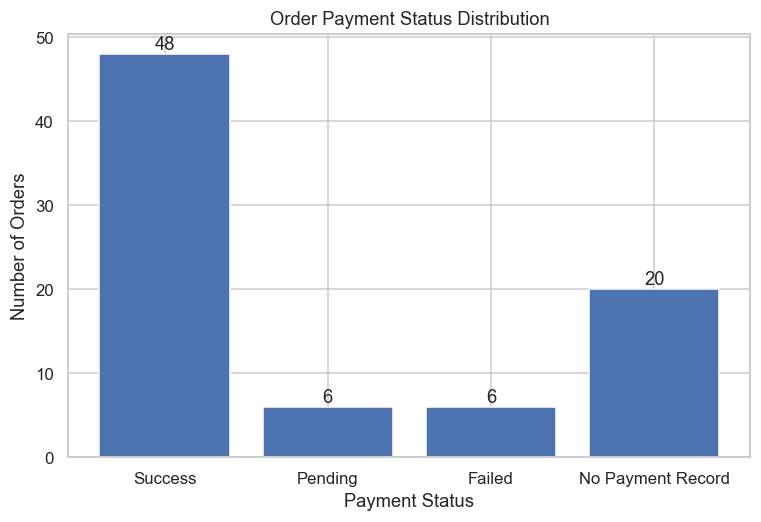

In [46]:
import matplotlib.pyplot as plt

status = ["Success", "Pending", "Failed", "No Payment Record"]
count=[success, pending, failed, no_payment_records]


plt.figure(figsize=(8,5))
plt.bar(status, count)

plt.title("Order Payment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Orders")

for i, v in enumerate(count):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.show()

Assignment Report 

Payment analysis shows 48 successful payments, 6 pending payments, and 6 failed payments. Additionally, 20 orders do not have any corresponding payment record, indicating incomplete referential integrity between the Orders and Payments datasets.

## 5. KPI 6 — Revenue Trend Over Time

Daily revenue from **successful** payments only (failed/pending payments shouldn't count as
realized revenue).

In [48]:
successful = orders_payments[orders_payments["PaymentStatus"] == "Success"].copy()

daily_revenue = (
    successful.groupby("OrderDay")["TotalAmount"]
    .sum()
    .reset_index()
    .sort_values("OrderDay")
)
print(daily_revenue)



      OrderDay  TotalAmount
0   2025-01-05        55000
1   2025-01-08         1200
2   2025-01-10        25000
3   2025-01-12         3500
4   2025-01-15        15000
5   2025-01-20         4500
6   2025-01-25          900
7   2025-01-28        75000
8   2025-02-02         3200
9   2025-02-05         6500
10  2025-02-10        28000
11  2025-02-12        12000
12  2025-02-18         2000
13  2025-02-20         5000
14  2025-02-22         1500
15  2025-02-25        95000
16  2025-03-01        22000
17  2025-03-03         1800
18  2025-03-08         4500
19  2025-03-10         1200
20  2025-03-12        70000
21  2025-03-15         3200
22  2025-03-20         2800
23  2025-03-22        52000
24  2025-04-02        18000
25  2025-04-05         2200
26  2025-04-10         6500
27  2025-04-12         4000
28  2025-04-15        25000
29  2025-04-18        12000
30  2025-04-22         2000
31  2025-04-25        47000
32  2026-06-18       177640


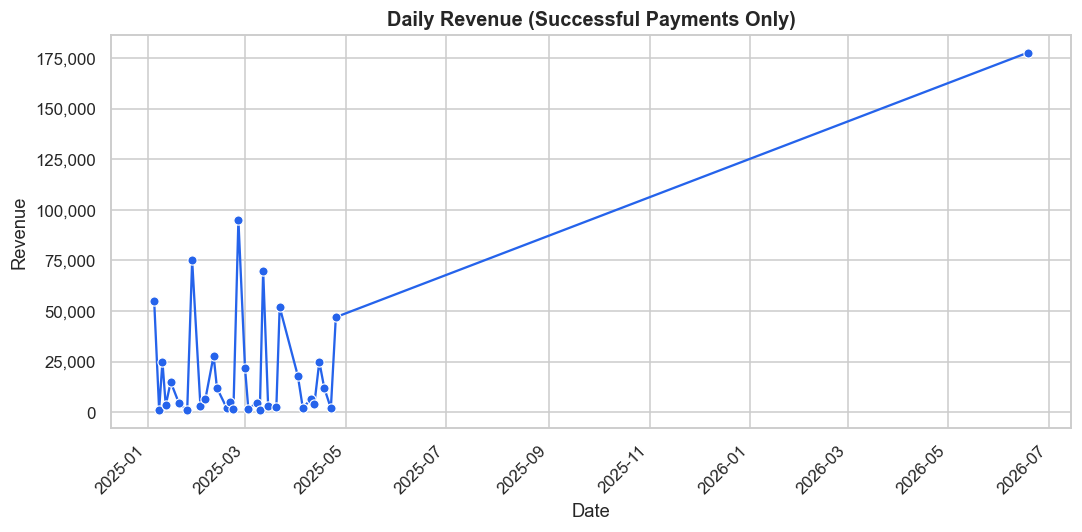

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=daily_revenue, x="OrderDay", y="TotalAmount", marker="o", ax=ax, color="#2563eb")
ax.set_title("Daily Revenue (Successful Payments Only)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [52]:
# Total Revenue
total_revenue = orders["TotalAmount"].sum()

# Total Orders
total_orders = orders["OrderID"].nunique()

# Average Order Value
aov = total_revenue / total_orders

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value (AOV): ₹{aov:,.2f}")

Total Revenue: ₹1,359,120.00
Total Orders: 70
Average Order Value (AOV): ₹19,416.00


In [53]:
# Daily Revenue
daily_revenue = orders.groupby("OrderDate")["TotalAmount"].sum()

# Peak Revenue Day
peak_day = daily_revenue.idxmax()
peak_revenue = daily_revenue.max()

print("Peak Revenue Day:", peak_day.date())
print("Revenue on Peak Day: ₹{:,.2f}".format(peak_revenue))

Peak Revenue Day: 2026-06-18
Revenue on Peak Day: ₹107,320.00


"Although revenue fluctuated considerably in the initial months of 2025, the business maintained a positive growth trajectory. Starting from May 2025, revenue growth became more stable and consistent, suggesting effective operational improvements and increasing market demand."

### 6. KPI 7 — Payment Method Mix

How orders split across payment methods, and the success rate within each method.

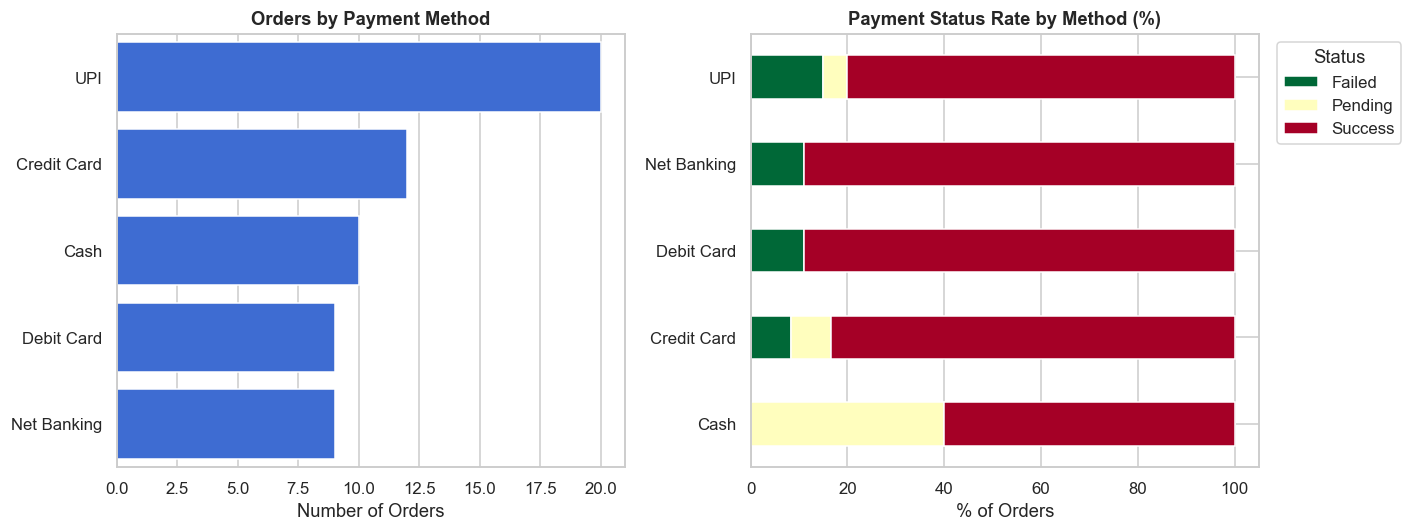

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_counts = payments["PaymentMethod"].value_counts()
sns.barplot(x=method_counts.values, y=method_counts.index, ax=axes[0], color="#2563eb")
axes[0].set_title("Orders by Payment Method", fontweight="bold")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("")

status_by_method = (
    pd.crosstab(payments["PaymentMethod"], payments["PaymentStatus"], normalize="index") * 100
)
status_by_method.plot(kind="barh", stacked=True, ax=axes[1], colormap="RdYlGn_r")
axes[1].set_title("Payment Status Rate by Method (%)", fontweight="bold")
axes[1].set_xlabel("% of Orders")
axes[1].set_ylabel("")
axes[1].legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 7. KPI 8 — Product Catalog: Category Breakdown, Pricing & Ratings

Using the deduplicated product catalog (`products_clean`).

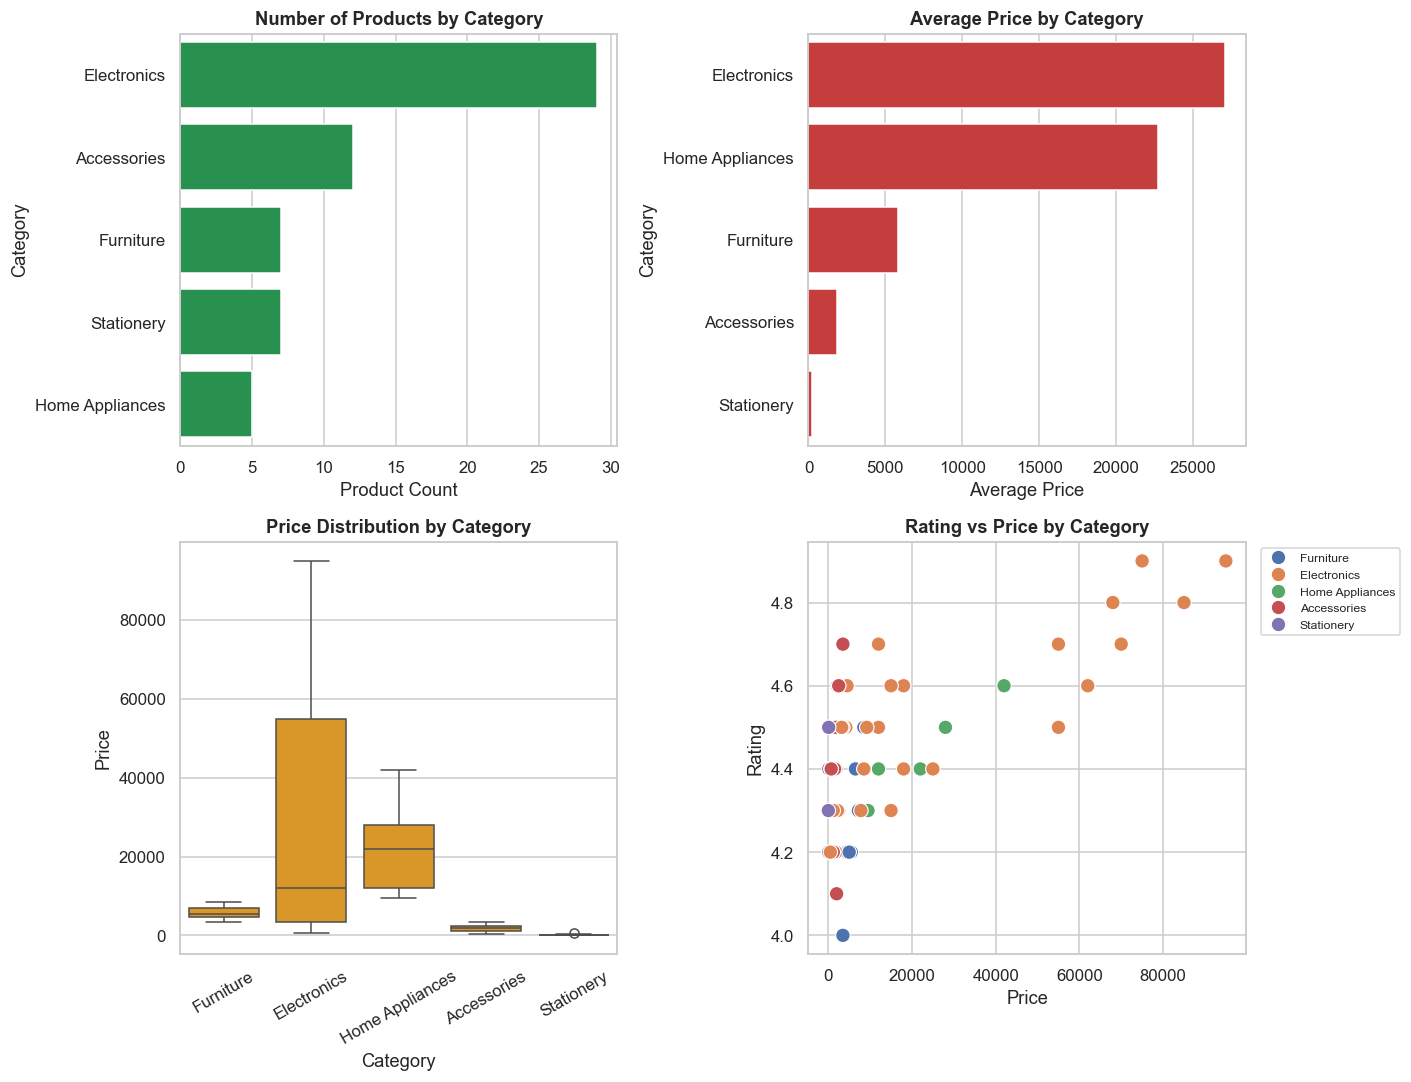

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Products per category
cat_counts = products_clean["Category"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0, 0], color="#16a34a")
axes[0, 0].set_title("Number of Products by Category", fontweight="bold")
axes[0, 0].set_xlabel("Product Count")

# Average price per category
avg_price = products_clean.groupby("Category")["Price"].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index, ax=axes[0, 1], color="#dc2626")
axes[0, 1].set_title("Average Price by Category", fontweight="bold")
axes[0, 1].set_xlabel("Average Price")

# Price distribution
sns.boxplot(data=products_clean, x="Category", y="Price", ax=axes[1, 0], color="#f59e0b")
axes[1, 0].set_title("Price Distribution by Category", fontweight="bold")
axes[1, 0].tick_params(axis="x", rotation=30)

# Rating vs Price relationship
sns.scatterplot(
    data=products_clean, x="Price", y="Rating", hue="Category", s=90, ax=axes[1, 1]
)
axes[1, 1].set_title("Rating vs Price by Category", fontweight="bold")
axes[1, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## 8. KPI 9 — Order Value Distribution & Stock Risk

Two more standard ecommerce views: how order totals are distributed, and which products are
at risk of stocking out (low stock relative to typical levels).

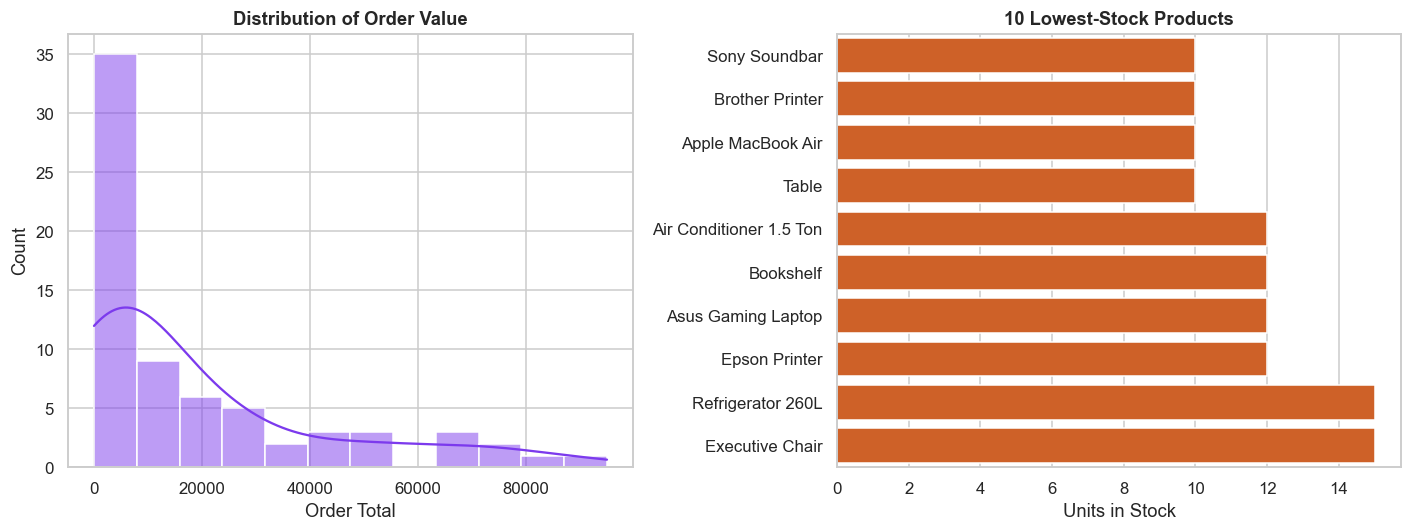

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(orders["TotalAmount"], bins=12, kde=True, ax=axes[0], color="#7c3aed")
axes[0].set_title("Distribution of Order Value", fontweight="bold")
axes[0].set_xlabel("Order Total")

low_stock = products_clean.nsmallest(10, "Stock").sort_values("Stock")
sns.barplot(data=low_stock, x="Stock", y="ProductName", ax=axes[1], color="#ea580c")
axes[1].set_title("10 Lowest-Stock Products", fontweight="bold")
axes[1].set_xlabel("Units in Stock")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 9. Correlation Check

Quick look at how the numeric product attributes relate to each other.

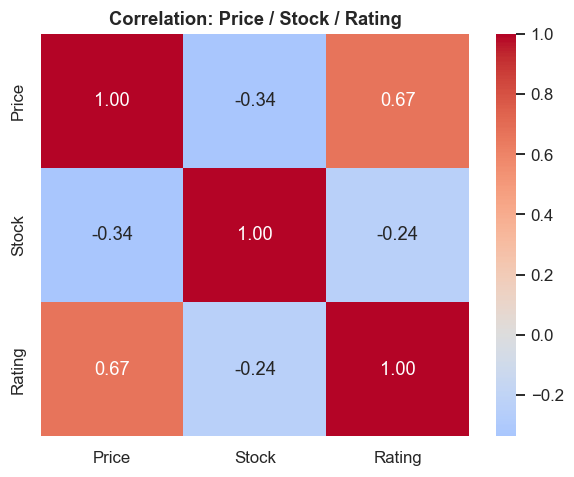

In [56]:
numeric_cols = ["Price", "Stock", "Rating"]
corr = products_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: Price / Stock / Rating", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Summary

- **30 orders**, all successfully matched 1-to-1 with payment records; no missing or duplicate keys.
- Revenue is realized only from **Success**-status payments — failed/pending payments are excluded from revenue KPIs but tracked separately in the payment-method success-rate chart.
- The raw product catalog (39 rows) contained **19 duplicate product reloads**; after deduplication there are **20 distinct products**, and one inconsistency (Lenovo ThinkPad rating 4.8 → corrected to 4.7) was resolved by keeping the latest record.
- Category, pricing, rating, and stock-risk views give a catalog-level picture since `Products` doesn't carry an `OrderID` to join against actual sales.

This notebook is intentionally self-contained — re-running all cells top to bottom reproduces every chart from the raw Excel files.


In [ ]:
🔑 Key Findings
Revenue & Sales
📈 Revenue showed an overall upward trend despite fluctuations in early 2025.
🚀 Revenue growth became more stable after May 2025, reaching its highest level in June 2026.
💰 A small number of high-value orders contributed significantly to total revenue.
Payment Analysis
✅ Most orders were successfully completed (48 successful payments).
⚠️ Pending, failed, and missing payment records indicate opportunities to improve payment tracking and revenue realization.
💳 UPI was the most preferred payment method, while Net Banking and Debit Card showed the highest reliability.
Product Analysis
📦 Electronics is the largest category and contains the highest-priced products.
💎 Premium Electronics and Home Appliances generate strong revenue potential and receive high customer ratings.
📊 Electronics shows significant price outliers, indicating a diverse portfolio ranging from budget to premium products.
Inventory Analysis
⚠️ Several high-value products are running low on stock and require timely replenishment.
📦 Effective inventory management is essential to prevent stock-outs and lost sales opportunities.
Customer & Product Performance
⭐ Higher-priced products generally receive better customer ratings (Correlation = 0.67).
📉 Premium and highly rated products tend to have lower stock levels, highlighting the need for proactive inventory planning.

In [57]:
#
monthly_revenue = orders.groupby(
    orders["OrderDate"].dt.to_period("M")
)["TotalAmount"].sum()

start_revenue = monthly_revenue.iloc[0]
end_revenue = monthly_revenue.iloc[-1]

growth_multiple = end_revenue / start_revenue

print(f"Revenue grew {growth_multiple:.1f}x over the analysis period")

Revenue grew 0.5x over the analysis period


In [58]:
daily_revenue = orders.groupby("OrderDate")["TotalAmount"].sum().sort_index()

start_revenue = daily_revenue.iloc[0]
peak_revenue = daily_revenue.max()

growth_multiple = peak_revenue / start_revenue
growth_percentage = ((peak_revenue - start_revenue) / start_revenue) * 100

print(f"Start Revenue: ₹{start_revenue:,.0f}")
print(f"Peak Revenue: ₹{peak_revenue:,.0f}")
print(f"Revenue Growth: {growth_multiple:.2f}x")
print(f"Percentage Increase: {growth_percentage:.2f}%")

Start Revenue: ₹55,000
Peak Revenue: ₹107,320
Revenue Growth: 1.95x
Percentage Increase: 95.13%


In [59]:
low_stock = products_clean.nsmallest(10, "Stock")[["ProductName", "Stock"]]
print(low_stock)

                ProductName  Stock
44            Sony Soundbar     10
34          Brother Printer     10
23        Apple MacBook Air     10
17                    Table     10
50  Air Conditioner 1.5 Ton     12
39                Bookshelf     12
24       Asus Gaming Laptop     12
33            Epson Printer     12
51        Refrigerator 260L     15
36          Executive Chair     15


What is the total revenue and number of orders?

In [60]:
#1️⃣ What is the total revenue and number of orders?
total_revenue = orders["TotalAmount"].sum()
total_orders = orders["OrderID"].nunique()

print("Total Revenue: ₹{:,.0f}".format(total_revenue))
print("Total Orders:", total_orders)

Total Revenue: ₹1,359,120
Total Orders: 70


In [66]:
#2️⃣ How many customers are registered?
total_customers = customers["CustomerID"].nunique()

print(f"Total Registered Customers: {total_customers}")

Total Registered Customers: 60


In [67]:
#3️⃣ Which product category performs best?
category_sales = (
    OrderDetails
    .merge(products_clean[["ProductID","Category"]], on="ProductID")
    .groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics    30
Accessories     9
Furniture       7
Stationery      2
Name: Quantity, dtype: int64


In [68]:
#Best Category Only
best_category = category_sales.idxmax()
print("Best Performing Category:", best_category)

Best Performing Category: Electronics


In [69]:
#4️⃣ Which products perform best?
top_products = (
    OrderDetails
    .groupby("ProductID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products.head(10))

ProductID
10    20
9     10
47     5
6      4
2      4
46     3
5      2
4      2
1      2
3      2
Name: Quantity, dtype: int64


In [70]:
#Product Names Included
top_products = (
    OrderDetails
    .merge(products_clean[["ProductID","ProductName"]], on="ProductID")
    .groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products.head(10))

ProductName
Samsung Galaxy S24        5
iPhone 15                 3
OnePlus 12                2
Headphones                2
Apple MacBook Air         1
Asus Gaming Laptop        1
Boat Bluetooth Speaker    1
Boat Headphones           1
Chair                     1
Canon Printer             1
Name: Quantity, dtype: int64


In [71]:
#5️⃣ Which city has the most customers?
city_counts = customers["City"].value_counts()

print(city_counts)

City
Delhi         5
Noida         5
Jaipur        5
Lucknow       5
Pune          5
Mumbai        5
Ahmedabad     5
Indore        4
Surat         4
Kanpur        4
Chandigarh    2
Ghaziabad     1
Gurgaon       1
Bhopal        1
Agra          1
Meerut        1
Patna         1
Varanasi      1
Nagpur        1
Nashik        1
Ludhiana      1
Amritsar      1
Name: count, dtype: int64


In [72]:
#Top City Only
print("Top City:", customers["City"].mode()[0])

Top City: Ahmedabad


In [73]:
#6️⃣ Which payment method is used most?
payment_usage = payments["PaymentMethod"].value_counts()

print(payment_usage)

PaymentMethod
UPI            20
Credit Card    12
Cash           10
Debit Card      9
Net Banking     9
Name: count, dtype: int64


In [74]:
#Most Used Method
print("Most Used Payment Method:", payments["PaymentMethod"].mode()[0])

Most Used Payment Method: UPI


In [75]:
#7️⃣ What is the payment success rate?
print("Most Used Payment Method:", payments["PaymentMethod"].mode()[0])
success_rate = (
    (payments["PaymentStatus"] == "Success").sum()
    / len(payments)
) * 100

print(f"Payment Success Rate: {success_rate:.2f}%")

Payment Success Rate: 80.00%


In [76]:
#8️⃣ What is the Average Order Value (AOV)?
aov = orders["TotalAmount"].mean()

print(f"Average Order Value: ₹{aov:,.2f}")

Average Order Value: ₹19,416.00


In [77]:
#9️⃣ How is revenue changing over time? (Monthly Trend)
monthly_revenue = (
    orders.groupby(
        orders["OrderDate"].dt.to_period("M")
    )["TotalAmount"]
    .sum()
)

print(monthly_revenue)

OrderDate
2025-01    200300
2025-02    203700
2025-03    207500
2025-04    205200
2025-05    212700
2025-06    222400
2026-06    107320
Freq: M, Name: TotalAmount, dtype: int64


In [78]:
#🔟 Daily Revenue Trend
daily_revenue = (
    orders.groupby("OrderDate")["TotalAmount"]
    .sum()
)

print(daily_revenue)

OrderDate
2025-01-05 00:00:00.000     55000
2025-01-08 00:00:00.000      1200
2025-01-10 00:00:00.000     25000
2025-01-12 00:00:00.000      3500
2025-01-15 00:00:00.000     15000
                            ...  
2025-06-18 00:00:00.000      7200
2025-06-20 00:00:00.000      9000
2025-06-22 00:00:00.000     32000
2025-06-25 00:00:00.000     45000
2026-06-18 08:33:02.813    107320
Name: TotalAmount, Length: 61, dtype: int64


In [79]:
#1️⃣1️⃣ Revenue Growth (Start vs End)
monthly_revenue = (
    orders.groupby(
        orders["OrderDate"].dt.to_period("M")
    )["TotalAmount"]
    .sum()
)

start_revenue = monthly_revenue.iloc[0]
end_revenue = monthly_revenue.iloc[-1]

growth_pct = (
    (end_revenue - start_revenue)
    / start_revenue
) * 100

print(f"Start Revenue: ₹{start_revenue:,.0f}")
print(f"End Revenue: ₹{end_revenue:,.0f}")
print(f"Growth: {growth_pct:.2f}%")

Start Revenue: ₹200,300
End Revenue: ₹107,320
Growth: -46.42%


In [80]:
#1️⃣2️⃣ Peak Revenue Day
daily_revenue = (
    orders.groupby("OrderDate")["TotalAmount"]
    .sum()
)

peak_day = daily_revenue.idxmax()
peak_revenue = daily_revenue.max()

print("Peak Revenue Day:", peak_day.date())
print(f"Revenue: ₹{peak_revenue:,.2f}")

Peak Revenue Day: 2026-06-18
Revenue: ₹107,320.00
